In [1]:
!pip install pyodbc

In [2]:
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'ODBC Driver 18 for SQL Server', 'ODBC Driver 17 for SQL Server']


In [3]:
import pyodbc

server = 'LAPTOP-R4ESBULM'
database = 'LeadAnalyticsDB'

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=LAPTOP-R4ESBULM;"
    "DATABASE=LeadAnalyticsDB;"
    "Trusted_Connection=yes;"
)

cursor = conn.cursor()

cursor.execute("SELECT table_name FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE='BASE TABLE'")

for row in cursor:
    print(row)

('Sales',)
('MarketingSpend',)
('Leads',)


In [4]:
import pandas as pd

In [5]:
leads_df = pd.read_sql("SELECT * FROM Leads", conn)
sales_df = pd.read_sql("SELECT * FROM Sales", conn)
marketing_df = pd.read_sql("SELECT * FROM MarketingSpend", conn)

C:\Users\valka\AppData\Local\Temp\ipykernel_14816\2867212855.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  leads_df = pd.read_sql("SELECT * FROM Leads", conn)
C:\Users\valka\AppData\Local\Temp\ipykernel_14816\2867212855.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql("SELECT * FROM Sales", conn)
C:\Users\valka\AppData\Local\Temp\ipykernel_14816\2867212855.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  marketing_df = pd.read_sql("SELECT * FROM MarketingSpend", conn)


In [6]:
print(leads_df.head())

   LeadID    Name      Company              Email     Phone    LeadSource  \
0       1  Lead_1    Company_7  lead1@example.com  9.19E+11      Referral   
1       2  Lead_2  Company_189  lead2@example.com  9.16E+11  Social Media   
2       3  Lead_3    Company_9  lead3@example.com  9.16E+11        Indeed   
3       4  Lead_4  Company_155  lead4@example.com  9.16E+11  Social Media   
4       5  Lead_5  Company_108  lead5@example.com  9.17E+11     Cold Call   

  ServiceInterested  FollowUpCount DateCreated     Status  
0          Meta Ads              1  2025-06-13  Contacted  
1               SEO              2  2025-02-27       Lost  
2          Meta Ads              6  2025-06-01  Converted  
3          Meta Ads              8  2025-03-01  Contacted  
4        Google Ads              8  2025-06-16        New  


In [7]:
print(sales_df.head())

   SaleID  LeadID  DealValue ClosingDate SalesPerson CampaignType
0       1       3   112015.0  2025-06-27       Rahul   Google Ads
1       2       9    46687.0  2025-02-11        Arun          SEO
2       3      10   100664.0  2025-05-28        Arun   Google Ads
3       4      21    70855.0  2025-06-06       Rahul          SEO
4       5      31   113993.0  2025-04-18       Rahul     Meta Ads


In [8]:
print(marketing_df.head())

   SpendID CampaignType   Month  SpendAmount  LeadsGenerated
0        1     Meta Ads  Jan-25      80772.0              70
1        2   Google Ads  Jan-25     105018.0             115
2        3          SEO  Jan-25     141915.0             118
3        4     Meta Ads  Feb-25     162241.0              61
4        5   Google Ads  Feb-25      86499.0              66


In [9]:
leads_df.fillna({
    "FollowUpCount": 0,
    "LeadSource": "Unknown"
}, inplace=True)

leads_df["DateCreated"] = pd.to_datetime(leads_df["DateCreated"])
sales_df["ClosingDate"] = pd.to_datetime(sales_df["ClosingDate"])

In [10]:
leads_df.isnull().sum()

LeadID               0
Name                 0
Company              0
Email                0
Phone                0
LeadSource           0
ServiceInterested    0
FollowUpCount        0
DateCreated          0
Status               0
dtype: int64

In [11]:
sales_df.isnull().sum()

SaleID          0
LeadID          0
DealValue       0
ClosingDate     0
SalesPerson     0
CampaignType    0
dtype: int64

In [12]:
marketing_df.isnull().sum()

SpendID           0
CampaignType      0
Month             0
SpendAmount       0
LeadsGenerated    0
dtype: int64

Conversion rate by lead source

In [13]:
conversion = leads_df.groupby("LeadSource")["Status"].apply(lambda x: (x=="Converted").sum() / len(x))

print(conversion)

LeadSource
Cold Call       0.205882
Indeed          0.192771
Referral        0.173913
Social Media    0.190000
Website         0.180000
Name: Status, dtype: float64


Revenue by campaign type

In [14]:
Revenue = sales_df.groupby("CampaignType")["DealValue"].sum()

print(Revenue)

CampaignType
Google Ads    2910345.0
Meta Ads      1640828.0
SEO           2818962.0
Name: DealValue, dtype: float64


Best-performing sales person

In [15]:
Best_SalesPerson = sales_df.groupby("SalesPerson")["DealValue"].sum()

print(Best_SalesPerson.sort_values(ascending=False))

SalesPerson
Sneha    2333184.0
Rahul    2244787.0
Arun     1458258.0
Priya    1333906.0
Name: DealValue, dtype: float64


Cost per lead

In [16]:
marketing_df["CostperLead"]=round(marketing_df["SpendAmount"]/marketing_df["LeadsGenerated"],2)
print(marketing_df)

    SpendID CampaignType   Month  SpendAmount  LeadsGenerated  CostperLead
0         1     Meta Ads  Jan-25      80772.0              70      1153.89
1         2   Google Ads  Jan-25     105018.0             115       913.20
2         3          SEO  Jan-25     141915.0             118      1202.67
3         4     Meta Ads  Feb-25     162241.0              61      2659.69
4         5   Google Ads  Feb-25      86499.0              66      1310.59
5         6          SEO  Feb-25     104248.0              47      2218.04
6         7     Meta Ads  Mar-25     199441.0              84      2374.30
7         8   Google Ads  Mar-25     189534.0              75      2527.12
8         9          SEO  Mar-25     191234.0              61      3134.98
9        10     Meta Ads  Apr-25     134843.0              77      1751.21
10       11   Google Ads  Apr-25     125846.0             113      1113.68
11       12          SEO  Apr-25     120082.0             105      1143.64
12       13     Meta Ads 

Campaign ROI calculation

In [17]:
merged = pd.merge(sales_df, marketing_df, on="CampaignType")
roi = merged.groupby("CampaignType").apply(lambda x: (x["DealValue"].sum() - x["SpendAmount"].sum()) / x["SpendAmount"].sum())
print(roi)

CampaignType
Google Ads   -0.373351
Meta Ads     -0.257923
SEO          -0.454531
dtype: float64


C:\Users\valka\AppData\Local\Temp\ipykernel_14816\732270199.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  roi = merged.groupby("CampaignType").apply(lambda x: (x["DealValue"].sum() - x["SpendAmount"].sum()) / x["SpendAmount"].sum())


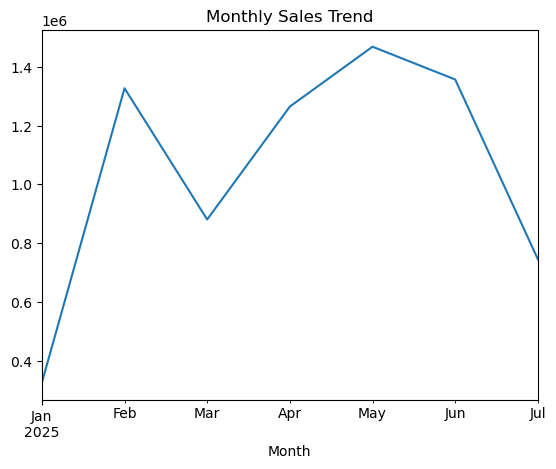

In [18]:
import matplotlib.pyplot as plt

sales_df["Month"] = sales_df["ClosingDate"].dt.to_period("M")

monthly_sales = sales_df.groupby("Month")["DealValue"].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

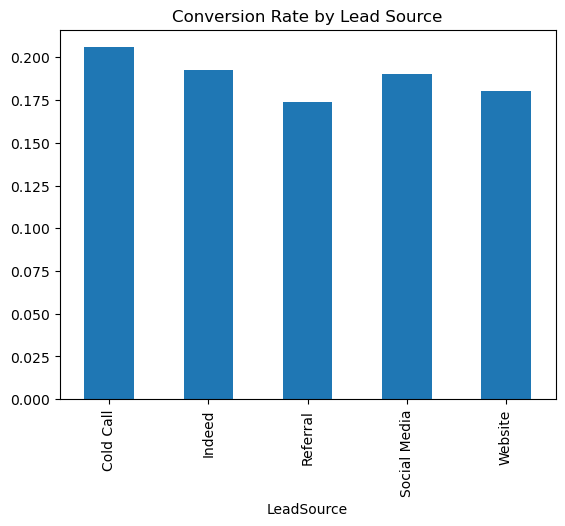

In [19]:
import matplotlib.pyplot as plt

conversion.plot(kind="bar")
plt.title("Conversion Rate by Lead Source")
plt.show()

In [20]:
# Convert target variable
leads_df["Converted"] = leads_df["Status"].apply(lambda x: 1 if x == "Converted" else 0)

In [21]:
df = leads_df.merge(sales_df, on="LeadID", how="left")

In [22]:
print(df.columns)

Index(['LeadID', 'Name', 'Company', 'Email', 'Phone', 'LeadSource',
       'ServiceInterested', 'FollowUpCount', 'DateCreated', 'Status',
       'Converted', 'SaleID', 'DealValue', 'ClosingDate', 'SalesPerson',
       'CampaignType', 'Month'],
      dtype='object')


In [23]:
print(df.duplicated().sum())

0


In [24]:
df["IsHighFollowUp"] = (df["FollowUpCount"] > 2).astype(int)
df["IsReferral"] = (df["LeadSource"] == "Referral").astype(int)
df["ServiceCategory"] = df["ServiceInterested"].astype("category").cat.codes

In [25]:
X = df[[
    "LeadSource",
    "ServiceInterested",
    "FollowUpCount",
    "IsHighFollowUp",
    "IsReferral",
    "ServiceCategory"
]].copy()

y=df["Converted"]

In [26]:
X.fillna({
    "LeadSource": "Unknown",
    "ServiceInterested": "Unknown",
    "FollowUpCount": 0
}, inplace=True)

In [27]:
print(X.head())

     LeadSource ServiceInterested  FollowUpCount  IsHighFollowUp  IsReferral  \
0      Referral          Meta Ads              1               0           1   
1  Social Media               SEO              2               0           0   
2        Indeed          Meta Ads              6               1           0   
3  Social Media          Meta Ads              8               1           0   
4     Cold Call        Google Ads              8               1           0   

   ServiceCategory  
0                1  
1                2  
2                1  
3                1  
4                0  


In [28]:
print(X.dtypes)

LeadSource           object
ServiceInterested    object
FollowUpCount         int64
IsHighFollowUp        int32
IsReferral            int32
ServiceCategory        int8
dtype: object


In [29]:
print(y.value_counts())

Converted
0    406
1     94
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import LabelEncoder

for col in ["LeadSource", "ServiceInterested"]:
    X[col] = LabelEncoder().fit_transform(X[col])

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7266666666666667


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr = LogisticRegression(class_weight='balanced')
rf = RandomForestClassifier(class_weight='balanced')

scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb_m1 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=5
)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb_m1.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, name):
    y_pred_model = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred_model))
    print("Precision:", precision_score(y_test, y_pred_model))
    print("Recall:", recall_score(y_test, y_pred_model))
    print("F1 Score:", f1_score(y_test, y_pred_model))

evaluate(lr, "Logistic Regression")
evaluate(rf, "Random Forest")
evaluate(xgb_m1, "XGBoost")


Logistic Regression
Accuracy: 0.4533333333333333
Precision: 0.17647058823529413
Recall: 0.3157894736842105
F1 Score: 0.22641509433962265

Random Forest
Accuracy: 0.6066666666666667
Precision: 0.16129032258064516
Recall: 0.13157894736842105
F1 Score: 0.14492753623188406

XGBoost
Accuracy: 0.5333333333333333
Precision: 0.19230769230769232
Recall: 0.2631578947368421
F1 Score: 0.2222222222222222


In [36]:
probs = xgb_m1.predict_proba(X_test)[:,1]

In [37]:
for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred_temp = (probs > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred_temp))
    print("Recall:", recall_score(y_test, y_pred_temp))
    print("Precision:", precision_score(y_test, y_pred_temp))


Threshold: 0.5
Accuracy: 0.5333333333333333
Recall: 0.2631578947368421
Precision: 0.19230769230769232

Threshold: 0.4
Accuracy: 0.52
Recall: 0.2631578947368421
Precision: 0.18518518518518517

Threshold: 0.3
Accuracy: 0.5
Recall: 0.39473684210526316
Precision: 0.22388059701492538

Threshold: 0.2
Accuracy: 0.4866666666666667
Recall: 0.5526315789473685
Precision: 0.25925925925925924


In [38]:
final_preds = (probs > 0.3).astype(int)
final_preds

array([0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1])

In [39]:
print(probs[:10])

[0.03079    0.7004962  0.6856159  0.04351911 0.68243176 0.02920322
 0.6598157  0.08478773 0.18021874 0.21467024]


In [40]:
from xgboost import XGBClassifier

xgb_m2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=5,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_m2.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [41]:
probs = xgb_m2.predict_proba(X_test)[:,1]

y_pred = (probs > 0.1).astype(int)

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.36666666666666664
Precision: 0.2336448598130841
Recall: 0.6578947368421053
F1 Score: 0.3448275862068966


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[30 82]
 [13 25]]


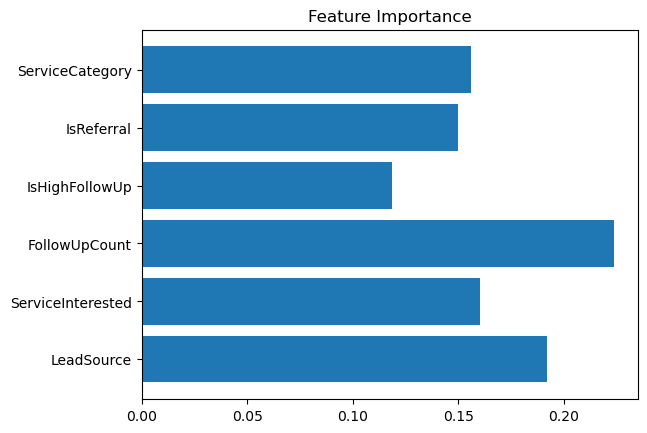

In [44]:
import matplotlib.pyplot as plt

features = X.columns
importance = xgb_m2.feature_importances_

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

Lead Scoring System

In [45]:
results = X_test.copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred
results["Conversion_Probability"] = probs

In [46]:
results["Lead_Score"] = (probs * 100).astype(int)

In [47]:
def lead_category(score):
    if score >= 70:
        return "Hot"
    elif score >= 40:
        return "Warm"
    else:
        return "Cold"

results["Lead_Type"] = results["Lead_Score"].apply(lead_category)

In [48]:
print(results.head())

     LeadSource  ServiceInterested  FollowUpCount  IsHighFollowUp  IsReferral  \
361           3                  1              8               1           0   
73            4                  1              6               1           0   
374           2                  2              5               1           1   
155           4                  2              1               0           0   
104           3                  2              4               1           0   

     ServiceCategory  Actual  Predicted  Conversion_Probability  Lead_Score  \
361                1       1          0                0.035580           3   
73                 1       0          1                0.626015          62   
374                2       0          1                0.737825          73   
155                2       0          1                0.191217          19   
104                2       0          1                0.699425          69   

    Lead_Type  
361      Cold  
73    

Customer Segmentation (K-Means)

In [49]:
X_cluster = pd.get_dummies(df[["LeadSource", "ServiceInterested", "CampaignType"]])

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.cluster import KMeans

scaled = scaler.fit_transform(X_cluster)
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled)

In [51]:
df.groupby("Cluster").mean(numeric_only=True)

,LeadID,FollowUpCount,Converted,SaleID,DealValue,IsHighFollowUp,IsReferral,ServiceCategory
Cluster,,,,,,,,
0,260.615385,5.307692,0.197802,51.194444,64267.222222,0.736264,0.005495,2.115385
1,246.410000,5.150000,0.133333,47.400000,85392.175000,0.733333,0.360000,1.180000
2,216.388889,4.333333,1.000000,40.333333,91157.111111,0.611111,0.333333,1.666667


In [52]:
results["Cluster"] = df.loc[X_test.index, "Cluster"]

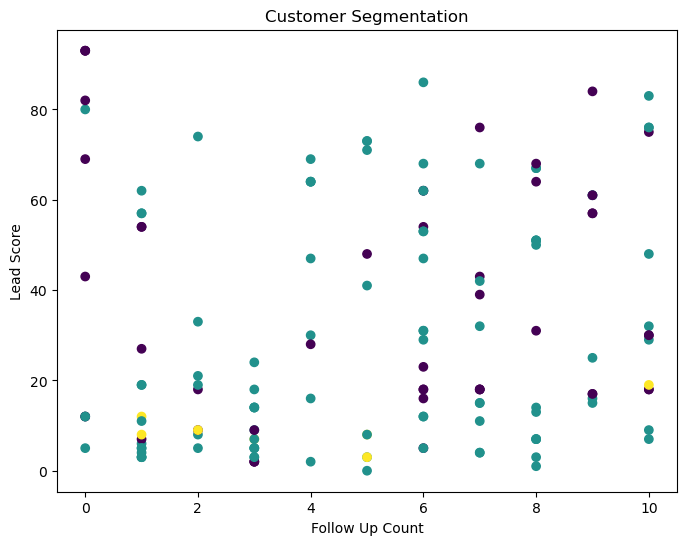

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    results["FollowUpCount"], 
    results["Lead_Score"], 
    c=results["Cluster"]
)

plt.xlabel("Follow Up Count")
plt.ylabel("Lead Score")
plt.title("Customer Segmentation")

plt.show()

In [54]:
import pickle
pickle.dump(xgb_m2, open("model.pkl", "wb"))